In [2]:
import pandas as pd
import joblib

model = joblib.load('random_forest_model.pkl')
scaler = joblib.load('scaler.pkl')

X_train_balanced = pd.read_csv('X_train_balanced.csv')
X_test_scaled = pd.read_csv('X_test_scaled.csv')
y_train_balanced = pd.read_csv('y_train_balanced.csv').squeeze()
y_test = pd.read_csv('y_test.csv').squeeze()

In [3]:
print('Model loaded:', model)
print('X_test_scaled shape:', X_test_scaled.shape)
print('y_test shape:', y_test.shape)

Model loaded: RandomForestClassifier(max_depth=10, random_state=42)
X_test_scaled shape: (854, 13)
y_test shape: (854,)


In [4]:
!pip install shap lime

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/12.0 MB ? eta -:--:--
   --------- ------------------------------ 2.9/12.0 MB 18.3 MB/s eta 0:00:01
   ----------- ---------------------------- 3.4/12.0 MB 11.1 MB/s eta 0:00:01
   ------------- -------------------------- 4.2/12.0 MB 6.3 MB/s eta 0:00:02
   ---------------- ----------------------- 5.0/12.0 MB 5.8 MB/s eta 0:00:02
   ------------------- -------------------- 5.8/12.0 MB 5.6 MB/s eta 0:00:02
   -------------------- ------------------- 6.3/12.0 MB 5.2 MB/s eta 0:00:02
   --------------------- ------------------ 6.6/12.0 MB 4.6 MB/s eta 0:00:02
   ---------------------- ----------------- 6.8/12.0 MB 4.2

In [5]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_scaled)

c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


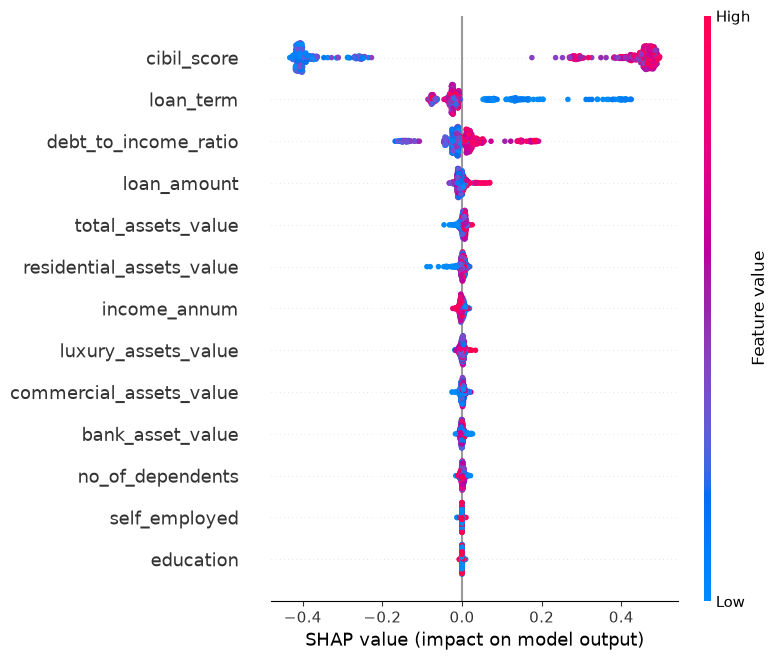

In [6]:
shap.summary_plot(shap_values[:, :, 1], X_test_scaled)

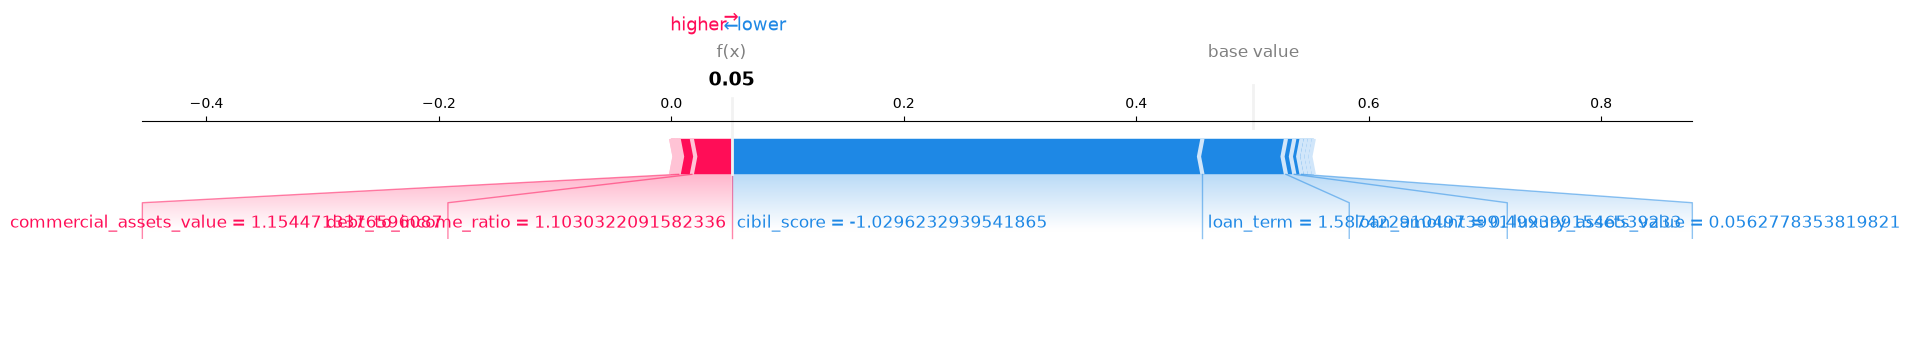

In [7]:
applicant_index = 0
shap.force_plot(explainer.expected_value[1], shap_values[applicant_index, :, 1], X_test_scaled.iloc[applicant_index, :], matplotlib=True)

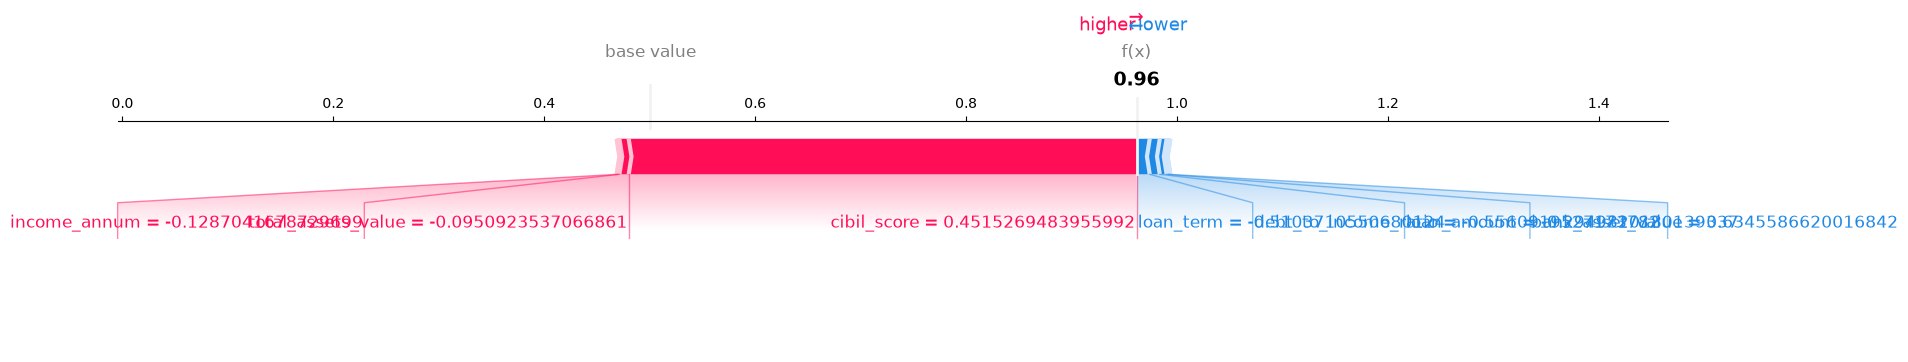

In [8]:
def explain_applicant(index):
    shap.force_plot(explainer.expected_value[1], shap_values[index, :, 1], X_test_scaled.iloc[index, :], matplotlib=True)

explain_applicant(5)

In [9]:
def what_if_cibil_score(index, new_cibil_score):
    applicant = X_test_scaled.iloc[[index]].copy()
    applicant['cibil_score'] = new_cibil_score
    prediction = model.predict_proba(applicant)[0][1]
    return prediction

In [11]:
import numpy as np

cibil_index = list(X_test_scaled.columns).index('cibil_score')
cibil_mean = scaler.mean_[cibil_index]
cibil_std = scaler.scale_[cibil_index]

def real_to_scaled_cibil(real_score):
    return (real_score - cibil_mean) / cibil_std

def scaled_to_real_cibil(scaled_score):
    return (scaled_score * cibil_std) + cibil_mean

In [12]:
original_scaled_cibil = X_test_scaled.iloc[0]['cibil_score']
original_real_cibil = scaled_to_real_cibil(original_scaled_cibil)
print('Original CIBIL score:', original_real_cibil)
print('Original approval probability:', model.predict_proba(X_test_scaled.iloc[[0]])[0][1])

new_real_cibil = 750
new_scaled_cibil = real_to_scaled_cibil(new_real_cibil)
new_probability = what_if_cibil_score(0, new_scaled_cibil)
print('If CIBIL score were', new_real_cibil, '-> approval probability:', new_probability)

Original CIBIL score: 423.0
Original approval probability: 0.05177984598303269
If CIBIL score were 750 -> approval probability: 0.9776434588947616


c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [13]:
def what_if_scenario(index, changes):
    applicant = X_test_scaled.iloc[[index]].copy()
    for feature, value in changes.items():
        applicant[feature] = value
    probability = model.predict_proba(applicant)[0][1]
    return probability

test_scores = [400, 500, 600, 650, 700, 750, 800]
for score in test_scores:
    scaled = real_to_scaled_cibil(score)
    prob = what_if_scenario(0, {'cibil_score': scaled})
    print(f'CIBIL score {score} -> approval probability: {prob:.2%}')

c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, bu

CIBIL score 400 -> approval probability: 4.38%
CIBIL score 500 -> approval probability: 5.18%
CIBIL score 600 -> approval probability: 96.69%
CIBIL score 650 -> approval probability: 97.69%
CIBIL score 700 -> approval probability: 97.76%
CIBIL score 750 -> approval probability: 97.76%
CIBIL score 800 -> approval probability: 97.76%
